In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
spark = SparkSession.builder \
    .appName("HyM-ACF-PACF") \
    .getOrCreate()

In [3]:
df = spark.read.parquet("merge_pyspark")
df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- article_id: long (nullable = true)
 |-- Fecha: date (nullable = true)
 |-- price: double (nullable = true)
 |-- sales_channel_id: long (nullable = true)
 |-- product_code: integer (nullable = true)
 |-- prod_name: string (nullable = true)
 |-- product_type_no: integer (nullable = true)
 |-- product_type_name: string (nullable = true)
 |-- product_group_name: string (nullable = true)
 |-- graphical_appearance_no: integer (nullable = true)
 |-- graphical_appearance_name: string (nullable = true)
 |-- colour_group_code: integer (nullable = true)
 |-- colour_group_name: string (nullable = true)
 |-- perceived_colour_value_id: integer (nullable = true)
 |-- perceived_colour_value_name: string (nullable = true)
 |-- perceived_colour_master_id: integer (nullable = true)
 |-- perceived_colour_master_name: string (nullable = true)
 |-- department_no: integer (nullable = true)
 |-- department_name: string (nullable = true)
 |-- index_code: str

In [4]:
df1 = df.filter((col("Fecha") >= "2018-09-20") & (col("Fecha") <= "2019-12-31"))
df2 = df.filter((col("Fecha") >= "2020-01-01") & (col("Fecha") <= "2020-09-22"))

print("Conjunto 1 (2018–2019):", df1.count(), "registros")
print("Conjunto 2 (2020):", df2.count(), "registros")

Conjunto 1 (2018–2019): 20808192 registros
Conjunto 2 (2020): 10980132 registros


In [5]:
df1_ts = df1.groupBy("Fecha").agg(avg("price").alias("avg_price")).orderBy("Fecha")
df2_ts = df2.groupBy("Fecha").agg(avg("price").alias("avg_price")).orderBy("Fecha")

In [6]:
pdf1_ts = df1_ts.toPandas().set_index("Fecha").sort_index()
pdf2_ts = df2_ts.toPandas().set_index("Fecha").sort_index()

<Figure size 1200x400 with 0 Axes>

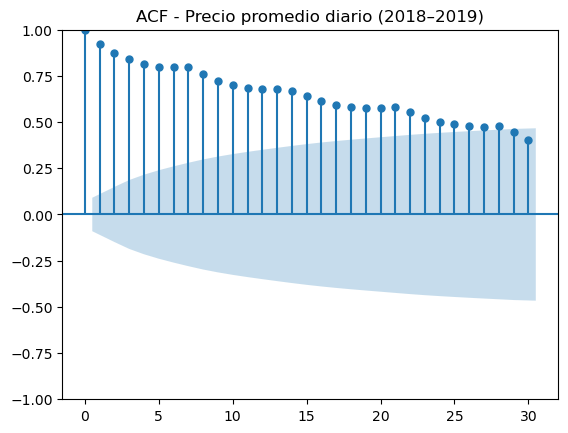

<Figure size 1200x400 with 0 Axes>

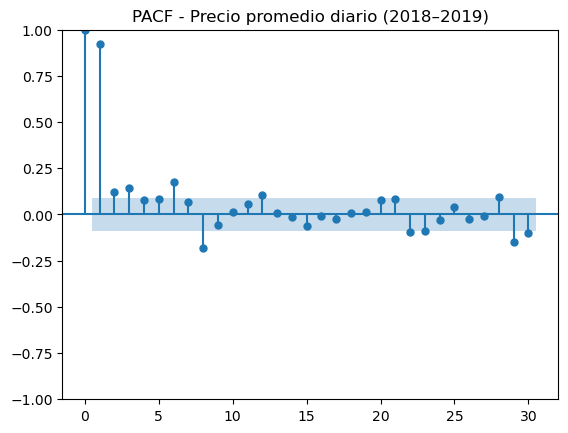

In [7]:
# --- Conjunto 1 (2018–2019)
serie1 = pdf1_ts["avg_price"].dropna()

plt.figure(figsize=(12,4))
plot_acf(serie1, lags=30)
plt.title("ACF - Precio promedio diario (2018–2019)")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(serie1, lags=30, method="ywm")
plt.title("PACF - Precio promedio diario (2018–2019)")
plt.show()

<Figure size 1200x400 with 0 Axes>

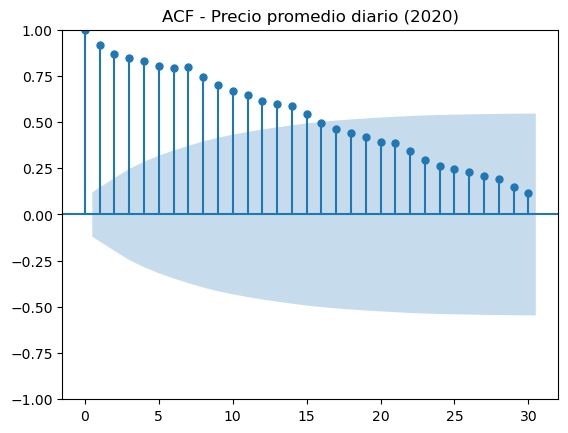

<Figure size 1200x400 with 0 Axes>

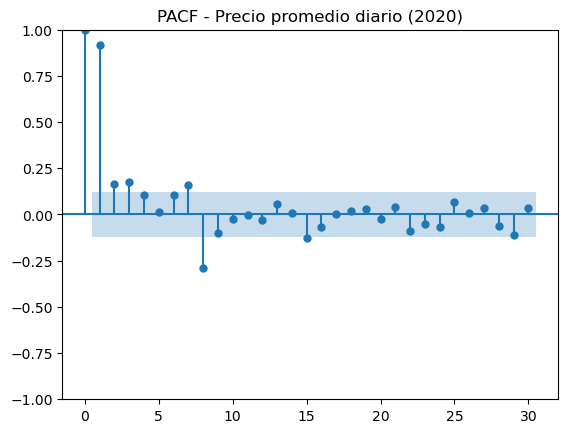

In [8]:
# --- Conjunto 2 (2020)
serie2 = pdf2_ts["avg_price"].dropna()

plt.figure(figsize=(12,4))
plot_acf(serie2, lags=30)
plt.title("ACF - Precio promedio diario (2020)")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(serie2, lags=30, method="ywm")
plt.title("PACF - Precio promedio diario (2020)")
plt.show()